In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pysrc.optimization import gams, gurobi
from pysrc.sampling import baseline
from pysrc.services.data_service import load_site_data
from pysrc.analysis import value_decomposition, transfers_decomposition

/Users/ph2696/Projects/project-amazon/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Model scenario

In [2]:
opt = "gurobi"
pee = 7.1
pa = 41.11
sitenum = 78
T = 200

In [3]:
# Load site data
(
    zbar_2017,
    z_2017,
    forest_area_2017,
    _,
    _,
    _,
    _,
) = load_site_data(sitenum)

# Set productivity parameters using baseline mean
baseline_fit = baseline.sample(
    num_sites=sitenum,
    iter_sampling=10**4,
    chains=5,
    seed=1,
)

theta = baseline_fit.stan_variable("theta").mean(axis=0)
gamma = baseline_fit.stan_variable("gamma").mean(axis=0)

# Computing carbon absorbed in start period
x0_vals = gamma * forest_area_2017

Data successfully loaded from /Users/ph2696/Projects/project-amazon/data/calibration/hmc


17:19:48 - cmdstanpy - INFO - compiling stan file /Users/ph2696/Projects/project-amazon/stan_model/baseline.stan to exe file /Users/ph2696/Projects/project-amazon/stan_model/baseline


Data successfully loaded from /Users/ph2696/Projects/project-amazon/data/calibration/hmc


17:19:52 - cmdstanpy - INFO - compiled model executable: /Users/ph2696/Projects/project-amazon/stan_model/baseline
17:19:52 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status







chain 1 |▊         | 00:00 Iteration:  700 / 10000 [  7%]  (Sampling)





chain 1 |██        | 00:00 Iteration: 2100 / 10000 [ 21%]  (Sampling)









chain 1 |███▏      | 00:00 Iteration: 3300 / 10000 [ 33%]  (Sampling)





chain 1 |████▍     | 00:00 Iteration: 4700 / 10000 [ 47%]  (Sampling)





chain 1 |█████▌    | 00:00 Iteration: 6000 / 10000 [ 60%]  (Sampling)





chain 1 |██████▊   | 00:00 Iteration: 7400 / 10000 [ 74%]  (Sampling)





chain 1 |██████████| 00:00 Sampling completed                        
chain 2 |██████████| 00:00 Sampling completed                        

chain 3 |██████████| 00:00 Sampling completed


chain 4 |██████████| 00:00 Sampling completed
chain 5 |██████████| 00:00 Sampling completed                        


17:19:53 - cmdstanpy - INFO - CmdStan done processing.


In [4]:
# Choose optimizer
if opt == "gurobi":
    solve_planner_problem = gurobi.solve_planner_problem

elif opt == "gams":
    solve_planner_problem = gams.solve_planner_problem

else:
    raise ValueError("Optimizer must be one of ['gurobi', 'gams']")

# Using same zetas 

In [5]:
results_base = solve_planner_problem(
    T=T,
    theta=theta,
    gamma=gamma,
    x0=x0_vals,
    zbar=zbar_2017,
    z0=z_2017,
    pe=pee,
    pa=pa,
)

results_transfer = solve_planner_problem(
    T=T,
    theta=theta,
    gamma=gamma,
    x0=x0_vals,
    zbar=zbar_2017,
    z0=z_2017,
    pe=pee + 5 * 5,
    pa=pa,
)

Solving the optimization problem...
Set parameter Username
Academic license - for non-commercial use only - expires 2024-10-30
Read LP format model from file /var/folders/d1/k6sr3htd7fdgk614mmq8pwq00000gr/T/tmp6zdt8fnc.pyomo.lp
Reading time = 0.34 seconds
x1: 31200 rows, 62401 columns, 124566 nonzeros
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (mac64[arm])

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 31200 rows, 62401 columns and 124566 nonzeros
Model fingerprint: 0x986f442e
Model has 1232400 quadratic objective terms
Coefficient statistics:
  Matrix range     [1e+00, 1e+03]
  Objective range  [3e-03, 1e+03]
  QObjective range [3e+03, 3e+05]
  Bounds range     [3e-04, 1e+00]
  RHS range        [6e-07, 7e+00]
Presolve removed 15600 rows and 15601 columns
Presolve time: 0.07s
Presolved: 15600 rows, 46800 columns, 62322 nonzeros
Presolved model has 1232400 quadratic objective terms
Ordering time: 0.01s

Barri

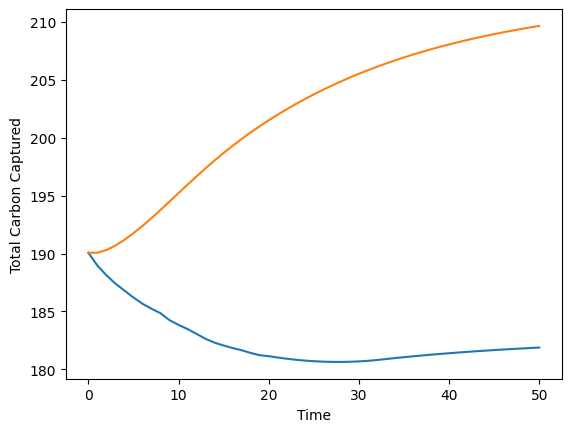

In [6]:
x_agg_base = results_base["X"].sum(axis=1)[:51]
x_agg_transfer = results_transfer["X"].sum(axis=1)[:51]

plt.plot(x_agg_base)
plt.plot(x_agg_transfer)

plt.ylabel("Total Carbon Captured")
plt.xlabel("Time")
plt.show()

In [7]:
Rs = []
VDs = []

for b in range(6):
    results = solve_planner_problem(
        T=T,
        theta=theta,
        gamma=gamma,
        x0=x0_vals,
        zbar=zbar_2017,
        z0=z_2017,
        pe=pee + b * 5,
        pa=pa,
    )

    v = value_decomposition(
        Z=results["Z"],
        X=results["X"],
        U=results["U"],
        V=results["V"],
        T=T,
        pee=pee,
        pa=pa,
        b=b * 5,
        theta=theta,
    )

    Rs.append(results)
    VDs.append(v)

Solving the optimization problem...
Set parameter Username
Academic license - for non-commercial use only - expires 2024-10-30
Read LP format model from file /var/folders/d1/k6sr3htd7fdgk614mmq8pwq00000gr/T/tmp3feqf6x2.pyomo.lp
Reading time = 0.34 seconds
x1: 31200 rows, 62401 columns, 124566 nonzeros
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (mac64[arm])

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 31200 rows, 62401 columns and 124566 nonzeros
Model fingerprint: 0x986f442e
Model has 1232400 quadratic objective terms
Coefficient statistics:
  Matrix range     [1e+00, 1e+03]
  Objective range  [3e-03, 1e+03]
  QObjective range [3e+03, 3e+05]
  Bounds range     [3e-04, 1e+00]
  RHS range        [6e-07, 7e+00]
Presolve removed 15600 rows and 15601 columns
Presolve time: 0.07s
Presolved: 15600 rows, 46800 columns, 62322 nonzeros
Presolved model has 1232400 quadratic objective terms
Ordering time: 0.01s

Barri

In [8]:
TDs = []

for b, results in enumerate(Rs):
    TDs.append(
        transfers_decomposition(
            years=15,
            Z=results["Z"],
            X=results["X"],
            Z_base=Rs[0]["Z"],
            X_base=Rs[0]["X"],
            b=b * 5,
        )
    )

/Users/ph2696/Projects/project-amazon/pysrc/analysis/__init__.py:88: RuntimeWarning: invalid value encountered in scalar divide
  total_EC = total_NT2 / (total_NCE - total_NCE_base)


In [15]:
print(pd.DataFrame(TDs).round(2).to_latex())

\begin{tabular}{lrrrr}
\toprule
 & b & net captured emissions & discounted net transfers & discounted effective costs \\
\midrule
0 & 0 & -10.130000 & 0.000000 & NaN \\
1 & 5 & 0.910000 & 3.140000 & 0.280000 \\
2 & 10 & 5.130000 & 42.890000 & 2.810000 \\
3 & 15 & 6.640000 & 83.750000 & 4.990000 \\
4 & 20 & 7.600000 & 128.250000 & 7.230000 \\
5 & 25 & 8.170000 & 172.900000 & 9.450000 \\
\bottomrule
\end{tabular}



# Using different zetas 

In [9]:
zeta = 0.000166 * 10**9

results_base = solve_planner_problem(
    T=T,
    theta=theta,
    gamma=gamma,
    x0=x0_vals,
    zbar=zbar_2017,
    z0=z_2017,
    pe=pee,
    pa=pa,
    zeta_u=zeta,
    zeta_v=zeta * 0.0001,
)

results_transfer = solve_planner_problem(
    T=T,
    theta=theta,
    gamma=gamma,
    x0=x0_vals,
    zbar=zbar_2017,
    z0=z_2017,
    pe=pee + 5 * 5,
    pa=pa,
    zeta_u=zeta,
    zeta_v=zeta * 0.0001,
)

Solving the optimization problem...
Set parameter Username
Academic license - for non-commercial use only - expires 2024-10-30
Read LP format model from file /var/folders/d1/k6sr3htd7fdgk614mmq8pwq00000gr/T/tmpurwpp0l7.pyomo.lp
Reading time = 0.34 seconds
x1: 31200 rows, 62401 columns, 124566 nonzeros
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (mac64[arm])

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 31200 rows, 62401 columns and 124566 nonzeros
Model fingerprint: 0xfff3c052
Model has 1232400 quadratic objective terms
Coefficient statistics:
  Matrix range     [1e+00, 1e+03]
  Objective range  [3e-03, 1e+03]
  QObjective range [3e-01, 3e+05]
  Bounds range     [3e-04, 1e+00]
  RHS range        [6e-07, 7e+00]
Presolve removed 15600 rows and 15601 columns
Presolve time: 0.07s
Presolved: 15600 rows, 46800 columns, 62322 nonzeros
Presolved model has 1232400 quadratic objective terms
Ordering time: 0.01s

Barri

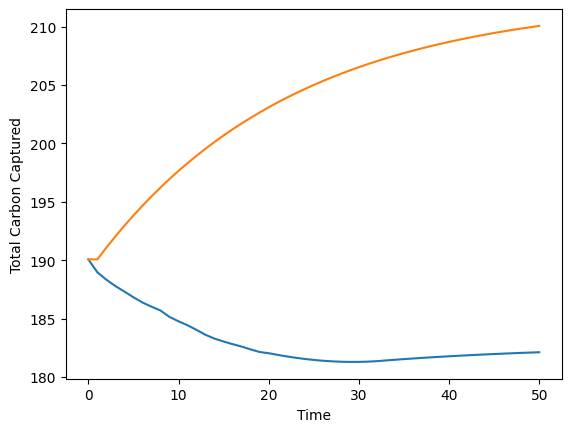

In [10]:
x_agg_base = results_base["X"].sum(axis=1)[:51]
x_agg_transfer = results_transfer["X"].sum(axis=1)[:51]

plt.plot(x_agg_base)
plt.plot(x_agg_transfer)

plt.ylabel("Total Carbon Captured")
plt.xlabel("Time")
plt.show()

In [11]:
Rs_asymm = []
VDs_asymm = []

for b in range(6):
    results = solve_planner_problem(
        T=T,
        theta=theta,
        gamma=gamma,
        x0=x0_vals,
        zbar=zbar_2017,
        z0=z_2017,
        pe=pee + b * 5,
        pa=pa,
        zeta_u=zeta,
        zeta_v=zeta * 0.0001,
    )

    v = value_decomposition(
        Z=results["Z"],
        X=results["X"],
        U=results["U"],
        V=results["V"],
        T=T,
        pee=pee,
        pa=pa,
        b=b * 5,
        theta=theta,
    )

    Rs_asymm.append(results)
    VDs_asymm.append(v)

Solving the optimization problem...
Set parameter Username
Academic license - for non-commercial use only - expires 2024-10-30
Read LP format model from file /var/folders/d1/k6sr3htd7fdgk614mmq8pwq00000gr/T/tmpum3aumt5.pyomo.lp
Reading time = 0.34 seconds
x1: 31200 rows, 62401 columns, 124566 nonzeros
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (mac64[arm])

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 31200 rows, 62401 columns and 124566 nonzeros
Model fingerprint: 0xfff3c052
Model has 1232400 quadratic objective terms
Coefficient statistics:
  Matrix range     [1e+00, 1e+03]
  Objective range  [3e-03, 1e+03]
  QObjective range [3e-01, 3e+05]
  Bounds range     [3e-04, 1e+00]
  RHS range        [6e-07, 7e+00]
Presolve removed 15600 rows and 15601 columns
Presolve time: 0.07s
Presolved: 15600 rows, 46800 columns, 62322 nonzeros
Presolved model has 1232400 quadratic objective terms
Ordering time: 0.01s

Barri

In [12]:
TDs_asymm = []

for b, results in enumerate(Rs_asymm):
    TDs_asymm.append(
        transfers_decomposition(
            years=15,
            Z=results["Z"],
            X=results["X"],
            Z_base=Rs_asymm[0]["Z"],
            X_base=Rs_asymm[0]["X"],
            b=b * 5,
        )
    )